# Moduel 7.5: Practice Notebook on Module 07 Data Preprocessing and Feature Engineering

In the previous practice day (6.5), you had already chosen **one dataset** from the list below and repeated the full EDA steps you learned in Module 06. For today’s practice (7.5), you will work on the topics you learned in Module 07: Data Preprocessing and Feature Engineering.

## Dataset Options (Choose One)

1. E-Commerce Fraud Detection Dataset  
   https://www.kaggle.com/datasets/umuttuygurr/e-commerce-fraud-detection-dataset  

2. BreastDataset  
   https://www.kaggle.com/datasets/khansaafreen/breastdataset  

3. Titanic Dataset  
   https://www.kaggle.com/datasets/yasserh/titanic-dataset  

4. Loan Approval Dataset  
   https://www.kaggle.com/datasets/anishdevedward/loan-approval-dataset  

5. Diabetes Health Indicators Dataset  
   https://www.kaggle.com/datasets/mohankrishnathalla/diabetes-health-indicators-dataset  

6. Alzheimer’s Disease Dataset  
   https://www.kaggle.com/datasets/rabieelkharoua/alzheimers-disease-dataset  

7. Students Performance Dataset  
   https://www.kaggle.com/datasets/rabieelkharoua/students-performance-dataset  

8. Cancer Data  
   https://www.kaggle.com/datasets/erdemtaha/cancer-data  

9. Mushroom Classification  
   https://www.kaggle.com/datasets/uciml/mushroom-classification  

10. Rain in Australia  
   https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package  

---


## Section 13 — Handling Missing Values

In [4]:
# TODO
import pandas as pd

from google.colab import files
uploaded = files.upload()
df_titanic = pd.read_csv("Titanic-Dataset.csv")
df_titanic.head(10)

Saving Titanic-Dataset.csv to Titanic-Dataset (2).csv


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [5]:
# Find Missing Values of your Dataset
df_titanic.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Distribution of Age Column


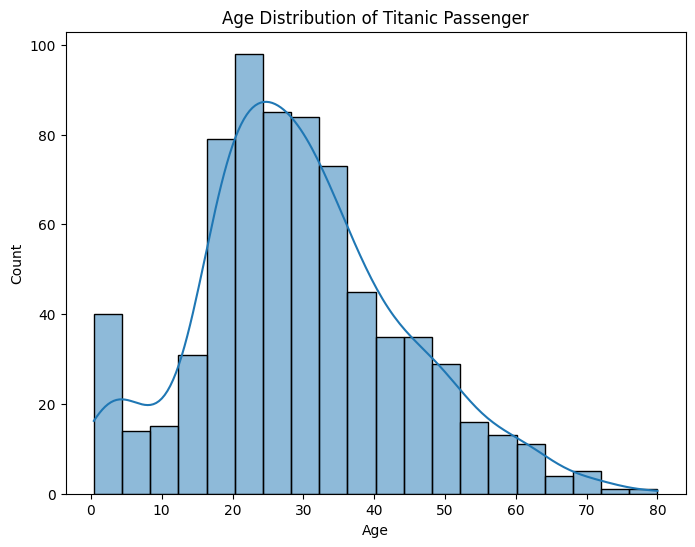

In [6]:
# Identify which way you should impute those missing values
# Apply the methods to impute missing values

print("Distribution of Age Column")
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.histplot(df_titanic["Age"], kde=True, bins=20)
plt.title("Age Distribution of Titanic Passenger")
plt.xlabel("Age")
plt.show()


Distribution of Embarked Column:


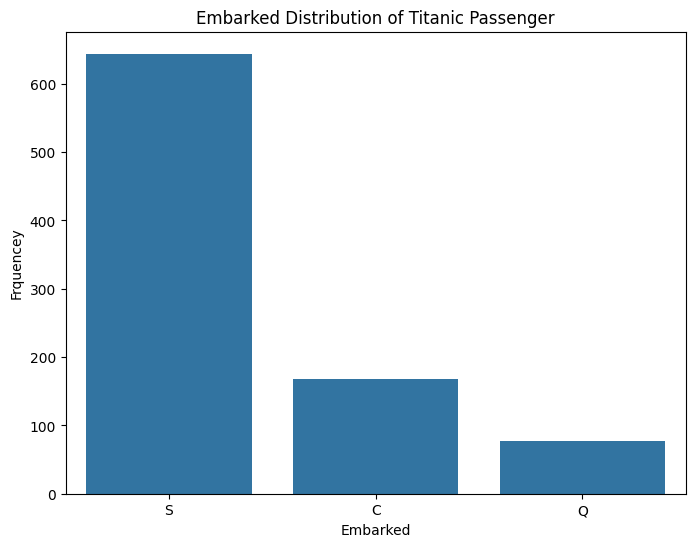

In [7]:
print("Distribution of Embarked Column:")
plt.figure(figsize=(8,6))
sns.countplot(data=df_titanic, x="Embarked")
plt.title("Embarked Distribution of Titanic Passenger")
plt.xlabel("Embarked")
plt.ylabel("Frquencey")
plt.show()

In [8]:
# 1. Handle numeric missing values: Age
age_median = df_titanic["Age"].median()
df_titanic["Age"] = df_titanic["Age"].fillna(age_median)

# 2. Handle categorical missing values: Embarked
embarked_mode = df_titanic["Embarked"].mode()[0]
df_titanic["Embarked"] = df_titanic["Embarked"].fillna(embarked_mode)

# 3. Drop Cabin (too many missing values)
df_titanic = df_titanic.drop(columns=["Cabin"])

In [9]:
print("Missing values after handling:")
df_titanic.isnull().sum()

Missing values after handling:


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


## Section 14 — Encoding Categorical Variables

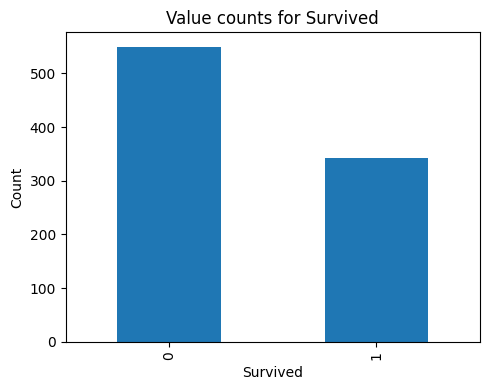

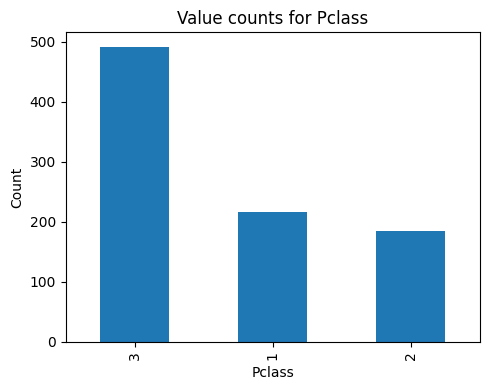

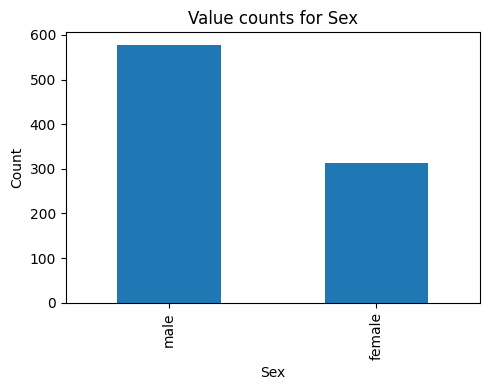

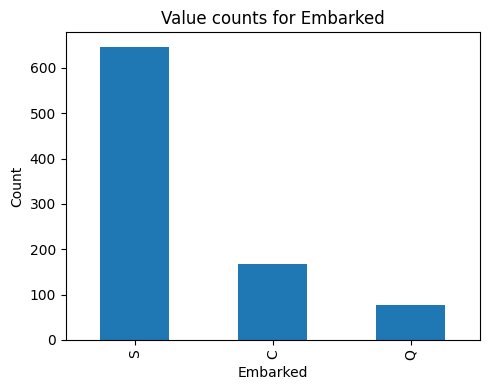

In [10]:
from pandas.core.arrays import categorical
# TODO
from sklearn.preprocessing import LabelEncoder

# Identify categorical features
categorical_cols = ["Survived", "Pclass", "Sex", "Embarked"]

# Take decision on what encoding will you apply for each categorical features
# Apply the methods to encode the features and show final data
for c in categorical_cols:
  plt.figure(figsize=(5,4))
  df_titanic[c].value_counts().plot(kind="bar")
  plt.title(f"Value counts for {c}")
  plt.ylabel("Count")
  plt.tight_layout()
  plt.show()

In [24]:
# Label Encoding for binary categorical columns -> Sex
le = LabelEncoder()
df_titanic["Sex"] = le.fit_transform(df_titanic["Sex"])
df_titanic["Embarked"] = le.fit_transform(df_titanic["Embarked"])

In [25]:
df_titanic.head(10)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,1,22.0,1,0,7.2500,2
1,2,1,1,0,38.0,1,0,71.2833,0
2,3,1,3,0,26.0,0,0,7.9250,2
3,4,1,1,0,35.0,1,0,53.1000,2
4,5,0,3,1,35.0,0,0,8.0500,2
5,6,0,3,1,28.0,0,0,8.4583,1
6,7,0,1,1,54.0,0,0,51.8625,2
7,8,0,3,1,2.0,3,1,21.0750,2
8,9,1,3,0,27.0,0,2,11.1333,2
9,10,1,2,0,14.0,1,0,30.0708,0


In [26]:
# OneHot Encoding for nominal categorical columns
cat_cols = ["Pclass","Embarked"]
df_titanic_encoded = pd.get_dummies(
    df_titanic,
    columns = cat_cols,
    dtype = int
)

In [27]:
df_titanic_encoded.head(10)

,PassengerId,Survived,Sex,Age,SibSp,Parch,Fare,Pclass_1,Pclass_2,Pclass_3,Embarked_0,Embarked_1,Embarked_2
0,1,0,1,22.0,1,0,7.2500,0,0,1,0,0,1
1,2,1,0,38.0,1,0,71.2833,1,0,0,1,0,0
2,3,1,0,26.0,0,0,7.9250,0,0,1,0,0,1
3,4,1,0,35.0,1,0,53.1000,1,0,0,0,0,1
4,5,0,1,35.0,0,0,8.0500,0,0,1,0,0,1
5,6,0,1,28.0,0,0,8.4583,0,0,1,0,1,0
6,7,0,1,54.0,0,0,51.8625,1,0,0,0,0,1
7,8,0,1,2.0,3,1,21.0750,0,0,1,0,0,1
8,9,1,0,27.0,0,2,11.1333,0,0,1,0,0,1
9,10,1,0,14.0,1,0,30.0708,0,1,0,1,0,0


In [28]:
df_titanic = df_titanic.drop(["Name", "Ticket"], axis=1)

In [29]:
df_titanic.head(10)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,1,22.0,1,0,7.2500,2
1,2,1,1,0,38.0,1,0,71.2833,0
2,3,1,3,0,26.0,0,0,7.9250,2
3,4,1,1,0,35.0,1,0,53.1000,2
4,5,0,3,1,35.0,0,0,8.0500,2
5,6,0,3,1,28.0,0,0,8.4583,1
6,7,0,1,1,54.0,0,0,51.8625,2
7,8,0,3,1,2.0,3,1,21.0750,2
8,9,1,3,0,27.0,0,2,11.1333,2
9,10,1,2,0,14.0,1,0,30.0708,0


## Section 15 — Normalization and Scaling

In [30]:
# TODO
# Check if your dataset have features with different range of values or not
# Take decision on whether scaling is required or not
# If required apply one of the scaling method

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Assume df_titanic_encoded is our working dataframe with target 'Survived'
target_col = "Survived"

X = df_titanic_encoded.drop(columns=[target_col])
y = df_titanic_encoded[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .25, random_state=42)

# Standard Scaling
scaler_sd = StandardScaler()
X_train_std = scaler_sd.fit_transform(X_train)
X_test_std = scaler_sd.transform(X_test)

# MinMax Scaling
scaler_mm = MinMaxScaler()
X_train_mm = scaler_mm.fit_transform(X_train)
X_test_mm = scaler_mm.transform(X_test)

print("\n--- Displaying Standard Scaled Data ---")
# Convert scaled arrays back to DataFrame for better visualization with column names
X_train_std_df = pd.DataFrame(X_train_std, columns = X_train.columns, index = X_train.index)
X_test_std_df = pd.DataFrame(X_test_std, columns = X_test.columns, index = X_test.index)
print("\nFirst 5 rows of X_train & X_test (Standard Scaled):")
display(X_train_std_df.head())
display(X_test_std_df.head())

print("\n--- Displaying Standard Scaled Data ---")
# Convert scaled arrays back to DataFrame for better visualization with column names
X_train_mm_df = pd.DataFrame(X_train_mm, columns = X_train.columns, index = X_train.index)
X_test_mm_df = pd.DataFrame(X_test_mm, columns = X_test.columns, index = X_test.index)

print("\nFirst 5 rows of X_train (Minmax Scaled):")
display(X_train_mm_df.head())
display(X_test_mm_df.head())


--- Displaying Standard Scaled Data ---

First 5 rows of X_train & X_test (Standard Scaled):


,PassengerId,Sex,Age,SibSp,Parch,Fare,Pclass_1,Pclass_2,Pclass_3,Embarked_0,Embarked_1,Embarked_2
298,-0.575735,0.722247,-0.087648,-0.467660,-0.468878,-0.032568,1.842481,-0.517254,-1.131311,-0.460805,-0.308354,0.595793
884,1.696946,0.722247,-0.318203,-0.467660,-0.468878,-0.487331,-0.542746,-0.517254,0.883931,-0.460805,-0.308354,0.595793
247,-0.773529,-1.384569,-0.395055,-0.467660,2.046870,-0.342854,-0.542746,1.933284,-1.131311,-0.460805,-0.308354,0.595793
478,0.122358,0.722247,-0.548758,-0.467660,-0.468878,-0.478201,-0.542746,-0.517254,0.883931,-0.460805,-0.308354,0.595793
305,-0.548587,0.722247,-2.168793,0.376656,2.046870,2.314937,1.842481,-0.517254,-1.131311,-0.460805,-0.308354,0.595793


,PassengerId,Sex,Age,SibSp,Parch,Fare,Pclass_1,Pclass_2,Pclass_3,Embarked_0,Embarked_1,Embarked_2
709,1.018244,0.722247,-0.087648,0.376656,0.788996,-0.328391,-0.542746,-0.517254,0.883931,2.170116,-0.308354,-1.678435
439,-0.028896,0.722247,0.142907,-0.467660,-0.468878,-0.420425,-0.542746,1.933284,-1.131311,-0.460805,-0.308354,0.595793
840,1.526301,0.722247,-0.702462,-0.467660,-0.468878,-0.470362,-0.542746,-0.517254,0.883931,-0.460805,-0.308354,0.595793
720,1.060906,-1.384569,-1.778386,-0.467660,0.788996,0.015914,-0.542746,1.933284,-1.131311,-0.460805,-0.308354,0.595793
39,-1.580214,-1.384569,-1.163572,0.376656,-0.468878,-0.406042,-0.542746,-0.517254,0.883931,2.170116,-0.308354,-1.678435



--- Displaying Standard Scaled Data ---

First 5 rows of X_train (Minmax Scaled):


,PassengerId,Sex,Age,SibSp,Parch,Fare,Pclass_1,Pclass_2,Pclass_3,Embarked_0,Embarked_1,Embarked_2
298,0.334831,1.0,0.346569,0.000,0.000000,0.059532,1.0,0.0,0.0,0.0,0.0,1.0
884,0.993258,1.0,0.308872,0.000,0.000000,0.013761,0.0,0.0,1.0,0.0,0.0,1.0
247,0.277528,0.0,0.296306,0.000,0.333333,0.028302,0.0,1.0,0.0,0.0,0.0,1.0
478,0.537079,1.0,0.271174,0.000,0.000000,0.014680,0.0,0.0,1.0,0.0,0.0,1.0
305,0.342697,1.0,0.006283,0.125,0.333333,0.295806,1.0,0.0,0.0,0.0,0.0,1.0


,PassengerId,Sex,Age,SibSp,Parch,Fare,Pclass_1,Pclass_2,Pclass_3,Embarked_0,Embarked_1,Embarked_2
709,0.796629,1.0,0.346569,0.125,0.166667,0.029758,0.0,0.0,1.0,1.0,0.0,0.0
439,0.493258,1.0,0.384267,0.000,0.000000,0.020495,0.0,1.0,0.0,0.0,0.0,1.0
840,0.943820,1.0,0.246042,0.000,0.000000,0.015469,0.0,0.0,1.0,0.0,0.0,1.0
720,0.808989,0.0,0.070118,0.000,0.166667,0.064412,0.0,1.0,0.0,0.0,0.0,1.0
39,0.043820,0.0,0.170646,0.125,0.000000,0.021942,0.0,0.0,1.0,1.0,0.0,0.0
